<a href="https://colab.research.google.com/github/rafiramdhan19/Kode-Implemtasi-EAS-Kelompok-8-Pembelajaran-Mesin/blob/main/Pembelajaran_Mesin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#DATASET
from google.colab import files
files.upload()

import os
print(os.listdir())

Saving Data Set Diabetes.zip to Data Set Diabetes.zip
['.config', 'Data Set Diabetes.zip', 'sample_data']


=== DATASET ===
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  

/tmp/ipykernel_15926/3734627041.py:73: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols] = df[cols].fillna(df[cols].median())


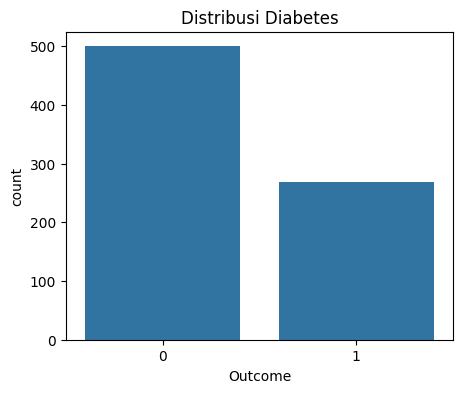

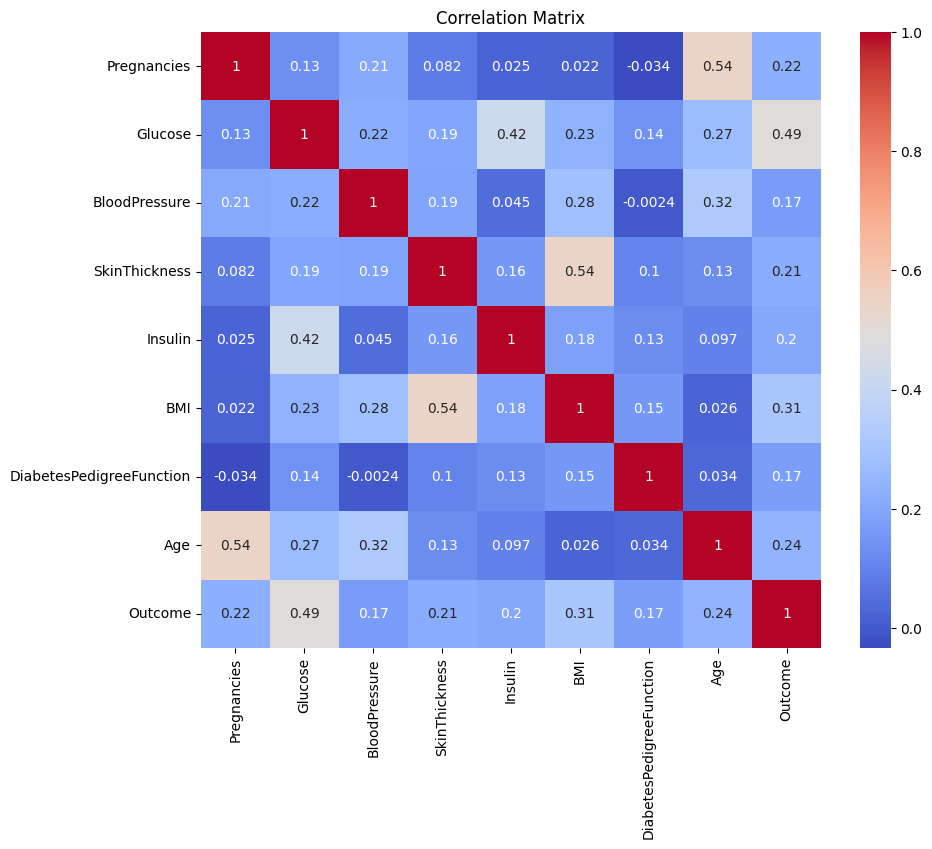

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6640 - loss: 0.7042 - val_accuracy: 0.6098 - val_loss: 0.7174
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6462 - val_accuracy: 0.6098 - val_loss: 0.6647
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6065 - val_accuracy: 0.6098 - val_loss: 0.6271
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6619 - loss: 0.5782 - val_accuracy: 0.6098 - val_loss: 0.5975
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6599 - loss: 0.5542 - val_accuracy: 0.6098 - val_loss: 0.5766
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.5368 - val_accuracy: 0.6098 - val_loss: 0.5599
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6741 - loss: 0.5234 - val_accuracy: 0.6098 - val_loss: 0.5464
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6721 - loss: 0.5124 - val_accuracy: 0.6423 - val_loss: 0.5338
Ep

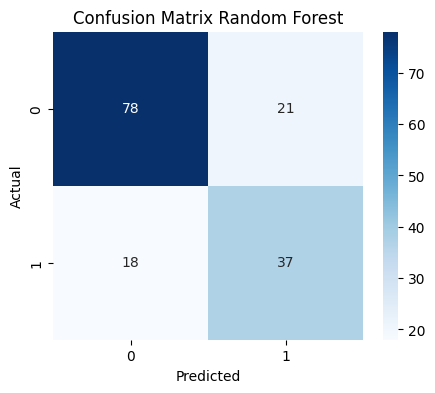


=== HYPERPARAMETER TUNING KNN ===
Best Parameter:
{'n_neighbors': 9}
Best Score:
0.7589897374383581

=== CROSS VALIDATION RANDOM FOREST ===
Cross Validation Score:
[0.76623377 0.74025974 0.74025974 0.83006536 0.74509804]
Rata-rata CV Score:
0.7643833290892115


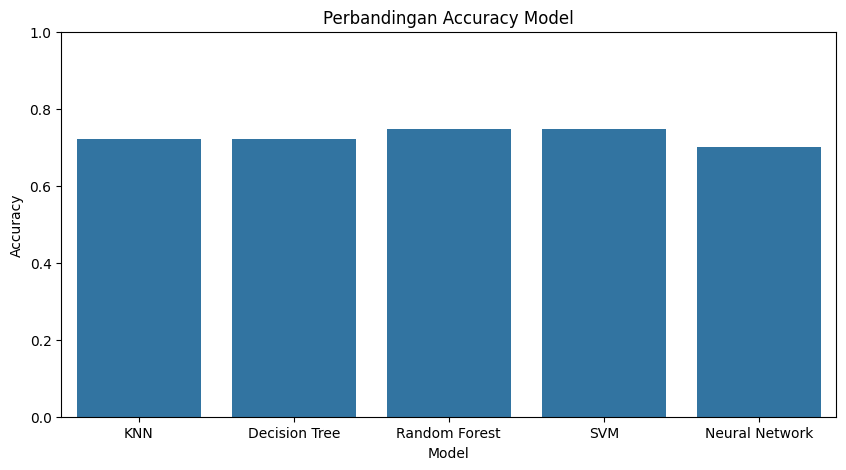

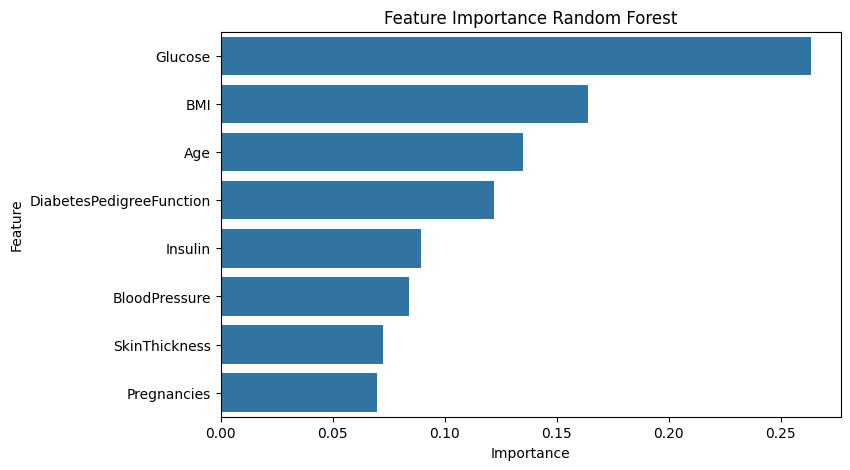


=== KESIMPULAN ===
Model terbaik adalah: Random Forest
Dengan accuracy: 0.747


In [ ]:
#  Rafi Ramdhan Bhaktiar     1462400140
#  Muhammad Fayiz Abdurrozaq 1462400116
#  Muhammad Ibnu Fahar       1462300225


# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile

# PREPROCESSING
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

# METRICS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# NON PARAMETRIC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# SVM
from sklearn import svm

# NEURAL NETWORK
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 2. EXTRACT DATASET
with zipfile.ZipFile('Data Set Diabetes.zip', 'r') as zip_ref:
    zip_ref.extractall('data')


# 3. LOAD DATASET
df = pd.read_csv('data/diabetes.csv')

print("=== DATASET ===")
print(df.head())


# 4. CEK INFO DATA
print("\n=== INFO DATA ===")
print(df.info())

# 5. HANDLE MISSING VALUE
cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Mengubah nilai 0 menjadi NA
df[cols] = df[cols].replace(0, pd.NA)

# Mengisi nilai kosong dengan median
df[cols] = df[cols].fillna(df[cols].median())

print("\n=== DATA SETELAH PREPROCESSING ===")
print(df.head())

# 6. EDA
# Distribusi Outcome
plt.figure(figsize=(5,4))

sns.countplot(
    x='Outcome',
    data=df
)

plt.title("Distribusi Diabetes")

plt.show()

# Heatmap Korelasi
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()


# 7. PEMISAHAN FITUR & LABEL
X = df.drop('Outcome', axis=1)
y = df['Outcome']


# 8. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 9. NORMALISASI
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. NON PARAMETRIC METHODS
# KNN
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn.predict(
    X_test_scaled
)


# DECISION TREE
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

y_pred_dt = dt.predict(
    X_test
)

# RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

# 11. SUPPORT VECTOR MACHINE (SVM)
svm_model = svm.SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

svm_model.fit(
    X_train_scaled,
    y_train
)

y_pred_svm = svm_model.predict(
    X_test_scaled
)

# 12. NEURAL NETWORK (MLP)
mlp = Sequential()

# Input Layer
mlp.add(Dense(
    16,
    activation='relu',
    input_shape=(X_train_scaled.shape[1],)
))

# Hidden Layer
mlp.add(Dense(
    8,
    activation='relu'
))

# Output Layer
mlp.add(Dense(
    1,
    activation='sigmoid'
))

# Compile
mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Training
history = mlp.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Prediksi
y_pred_mlp = mlp.predict(
    X_test_scaled
)

# Konversi probabilitas menjadi kelas
y_pred_mlp = (
    y_pred_mlp > 0.5
).astype(int)


# 13. EVALUASI MODEL
def evaluasi_model(
    nama,
    y_true,
    y_pred
):

    acc = accuracy_score(
        y_true,
        y_pred
    )

    return {

        "Model": nama,

        "Accuracy": acc,

        "Error": 1 - acc,

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

hasil = pd.DataFrame([

    evaluasi_model(
        "KNN",
        y_test,
        y_pred_knn
    ),

    evaluasi_model(
        "Decision Tree",
        y_test,
        y_pred_dt
    ),

    evaluasi_model(
        "Random Forest",
        y_test,
        y_pred_rf
    ),

    evaluasi_model(
        "SVM",
        y_test,
        y_pred_svm
    ),

    evaluasi_model(
        "Neural Network",
        y_test,
        y_pred_mlp
    )

])

hasil = hasil.round(3)

print("\n=== HASIL EVALUASI MODEL ===")
print(hasil)

# 14. CLASSIFICATION REPORT
print("\n=== CLASSIFICATION REPORT SVM ===")

print(classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
))

# 15. CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix Random Forest")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 16. HYPERPARAMETER TUNING
print("\n=== HYPERPARAMETER TUNING KNN ===")

param_grid = {
    'n_neighbors': [3,5,7,9]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

grid.fit(
    X_train_scaled,
    y_train
)

print("Best Parameter:")
print(grid.best_params_)

print("Best Score:")
print(grid.best_score_)

# 17. CROSS VALIDATION
print("\n=== CROSS VALIDATION RANDOM FOREST ===")

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Cross Validation Score:")
print(cv_scores)

print("Rata-rata CV Score:")
print(cv_scores.mean())

# 18. VISUALISASI PERBANDINGAN MODEL
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=hasil
)

plt.title("Perbandingan Accuracy Model")

plt.ylim(0,1)

plt.show()


# 19. FEATURE IMPORTANCE
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance Random Forest")

plt.show()

# 20. KESIMPULAN
print("\n=== KESIMPULAN ===")

best_model = hasil.loc[
    hasil['Accuracy'].idxmax()
]

print(
    "Model terbaik adalah:",
    best_model['Model']
)

print(
    "Dengan accuracy:",
    best_model['Accuracy']
)

=== DATASET ===
   Feature_1  Feature_2
0  -7.338988  -7.729954
1  -7.740041  -7.264665
2  -1.686653   7.793442
3   4.422198   3.071947
4  -8.917752  -7.888196


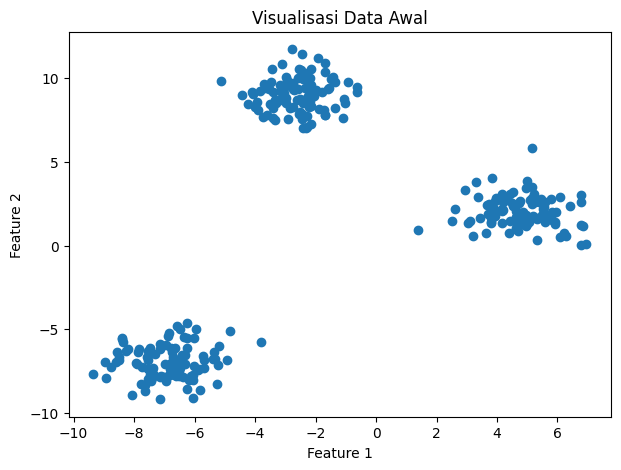


=== HASIL CLUSTERING ===
   Feature_1  Feature_2  Cluster
0  -7.338988  -7.729954        1
1  -7.740041  -7.264665        1
2  -1.686653   7.793442        0
3   4.422198   3.071947        2
4  -8.917752  -7.888196        1

=== CENTROID ===
[[-0.21277029  1.15926337]
 [-1.07970061 -1.25787405]
 [ 1.2924709   0.09861068]]


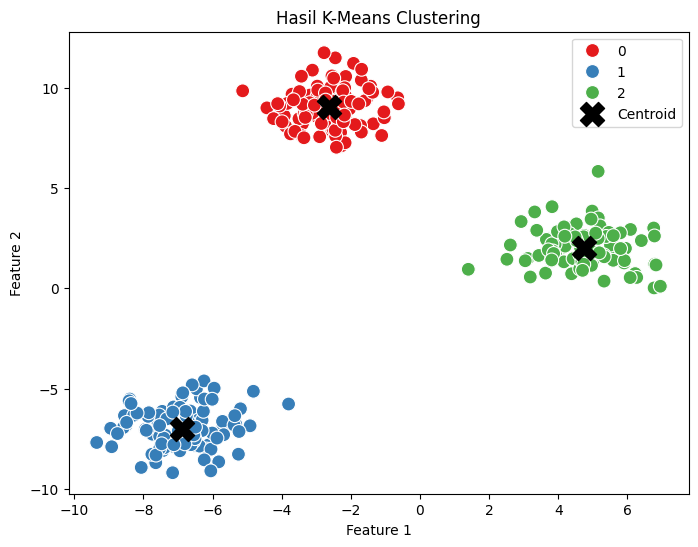


=== INFORMASI MODEL ===
Jumlah Cluster :
3

Nilai Inertia :
18.26315933089595


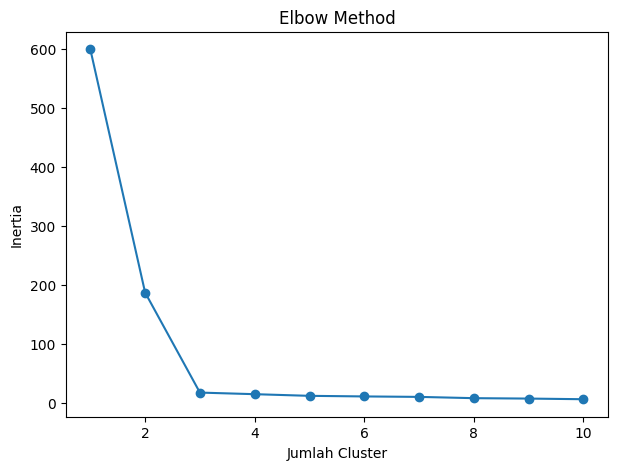


=== KESIMPULAN ===
Model K-Means berhasil mengelompokkan data menjadi 3 cluster.


In [ ]:
# IMPLEMENTASI AWAL MODEL K-MEANS CLUSTERING DALAM PYTHON

# IMPORT LIBRARY
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs


# MEMBUAT DATASET DUMMY
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# MENGUBAH KE DATAFRAME
df = pd.DataFrame(
    X,
    columns=['Feature_1', 'Feature_2']
)

# MENAMPILKAN DATASET
print("=== DATASET ===")
print(df.head())


# VISUALISASI DATA AWAL
plt.figure(figsize=(7,5))

plt.scatter(
    df['Feature_1'],
    df['Feature_2']
)

plt.title("Visualisasi Data Awal")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()


# NORMALISASI DATA
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)


# MENENTUKAN JUMLAH CLUSTER
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# TRAINING MODEL
kmeans.fit(X_scaled)

# PREDIKSI CLUSTER
clusters = kmeans.predict(X_scaled)

# MENAMBAHKAN HASIL CLUSTER KE DATAFRAME
df['Cluster'] = clusters

print("\n=== HASIL CLUSTERING ===")
print(df.head())


# MENAMPILKAN CENTROID
print("\n=== CENTROID ===")
print(kmeans.cluster_centers_)


# VISUALISASI HASIL CLUSTERING
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

# MENAMPILKAN TITIK CENTROID
centroids = scaler.inverse_transform(
    kmeans.cluster_centers_
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='black',
    s=300,
    marker='X',
    label='Centroid'
)

plt.title("Hasil K-Means Clustering")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()

plt.show()


# EVALUASI MODEL
print("\n=== INFORMASI MODEL ===")

print("Jumlah Cluster :")
print(kmeans.n_clusters)

print("\nNilai Inertia :")
print(kmeans.inertia_)


# ELBOW METHOD
inertia = []

K = range(1, 11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

# VISUALISASI ELBOW METHOD
plt.figure(figsize=(7,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")

plt.show()


# KESIMPULAN
print("\n=== KESIMPULAN ===")

print(
    "Model K-Means berhasil mengelompokkan data menjadi 3 cluster."
)

In [ ]:
#Source Code PCA
# IMPORT LIBRARY
import pandas as pd
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# UPLOAD DATASET
uploaded = files.upload()

# MENAMPILKAN 5 DATA PERTAMA
print(df.head())

# MEMISAHKAN FITUR DAN LABEL
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# NORMALISASI DATA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Shape Data Awal :", X.shape)
print("Shape Setelah PCA :", X_pca.shape)

print("\n5 Data Pertama Hasil PCA")
print(X_pca[:5])

Saving Data Set Diabetes.zip to Data Set Diabetes (2).zip
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Shape Data Awal : (768, 8)
Shape Setelah PCA : (768, 2)

5 Data Pertama Hasil PCA
[[ 1.44948091  0.65976875]
 [-1.49883475 -0.07604933]
 [ 0.42324603  0.76132708]
 [-2.15246812 -0.16671733]
 [ 0.69783636 -3.54895194]]


In [ ]:
#SOurce Code PLA
# IMPORT LIBRARY
import pandas as pd
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# UPLOAD DATASET
uploaded = files.upload()

# MENAMPILKAN 5 DATA PERTAMA
print(df.head())

# MEMISAHKAN FITUR DAN LABEL
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# NORMALISASI DATA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LDA
lda = LinearDiscriminantAnalysis(
    n_components=1
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

# HASIL LDA
print("Shape Data Awal :", X.shape)
print("Shape Setelah LDA :", X_lda.shape)

print("\n5 Data Pertama Hasil LDA")
print(X_lda[:5])

Saving Data Set Diabetes.zip to Data Set Diabetes (4).zip
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Shape Data Awal : (768, 8)
Shape Setelah LDA : (768, 1)

5 Data Pertama Hasil LDA
[[ 1.31346005]
 [-1.76653005]
 [ 1.75188508]
 [-1.73651521]
 [ 2.01171512]]


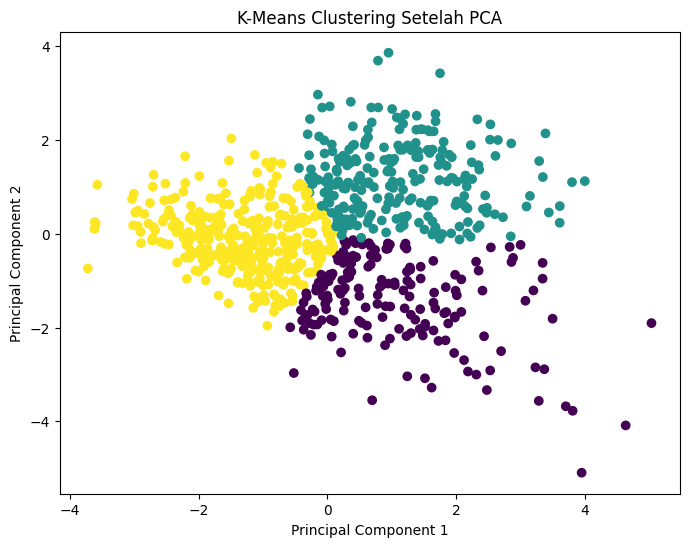

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# K-MEANS
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

# VISUALISASI
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title("K-Means Clustering Setelah PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [ ]:
import random
import time
from IPython.display import clear_output
import gymnasium as gym
import numpy as np

# 1. INISIALISASI ENVIRONMENT (MENGGUNAKAN TAXI-V4)
# Menggunakan Taxi-v4 karena versi v3 sudah deprecated di gymnasium terbaru
env = gym.make("Taxi-v4", render_mode="ansi")

# Reset environment untuk mendapatkan state awal
state, info = env.reset()

print("=== INFORMASI ENVIRONMENT ===")
print("Action Space :", env.action_space)
print("State Space  :", env.observation_space)

# Menggunakan .unwrapped agar bisa mengakses fungsi .encode() pada objek asli
state = env.unwrapped.encode(3, 1, 2, 0)
print("State Terpilih (Kondisi Manual):", state)

# Set posisi internal taxi ke state hasil encode
env.unwrapped.s = state


# 2. SIMULASI AGEN ACAK (RANDOM WALK) SEBELUM TRAINING

epochs = 0
penalties, reward = 0, 0
frames = []  # Menyimpan frame untuk animasi visualisasi
done = False

while not done:
    action = env.action_space.sample()  # Memilih aksi secara acak

    # Pustaka Gymnasium mengembalikan tuple isi 5 nilai
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    # Penalti -10 diberikan jika agen salah melakukan pick-up atau drop-off
    if reward == -10:
        penalties += 1

    # Menyimpan render teks ke dalam list frame
    frames.append(
        {
            "frame": env.render(),
            "state": state,
            "action": action,
            "reward": reward,
        }
    )
    epochs += 1

print("\n=== HASIL PERFORMA AGEN ACAK ===")
print(f"Timesteps (Langkah) diambil : {epochs}")
print(f"Penalti yang diterima       : {penalties}")


# Fungsi opsional untuk melihat pergerakan taksi secara visual di notebook
def print_frames(frames):
    for i, frame in enumerate(frames):
        clear_output(wait=True)
        print(frame["frame"])
        print(f"Timestep: {i + 1}")
        print(f"State   : {frame['state']}")
        print(f"Action  : {frame['action']}")
        print(f"Reward  : {frame['reward']}")
        time.sleep(0.1)


# Hilangkan tanda pagar (#) di bawah ini jika ingin melihat animasinya berjalan:
# print_frames(frames)

# 3. PROSES TRAINING AGEN MENGGUNAKAN Q-LEARNING
# Membuat Q-Table dengan ukuran [Jumlah_State, Jumlah_Aksi] (500 x 6)
q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Hyperparameters
alpha = 0.1  # Learning rate (Tingkat pembelajaran)
gamma = 0.6  # Discount factor (Faktor diskon nilai masa depan)
epsilon = 0.1  # Exploration rate (Rasio eksplorasi aksi acak)

print("\n=== MEMULAI PROSES TRAINING AGEN (100.000 EPISODE) ===")
for i in range(1, 100001):
    state, info = env.reset()

    epochs, penalties, reward = 0, 0, 0
    done = False

    while not done:
        # Strategi Epsilon-Greedy
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Eksplorasi: Pilih aksi acak
        else:
            action = np.argmax(
                q_table[state]
            )  # Eksploitasi: Pilih aksi terbaik dari Q-Table

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Implementasi Rumus Update Q-Value (Persamaan Bellman)
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])

        new_value = (1 - alpha) * old_value + alpha * (
            reward + gamma * next_max
        )
        q_table[state, action] = new_value

        if reward == -10:
            penalties += 1

        state = next_state
        epochs += 1

    # Menampilkan progres setiap 20.000 episode agar output bersih
    if i % 20000 == 0:
        print(f"Progres: Episode {i} telah diselesaikan.")

print("Training Selesai dan Q-Table Telah Optimal.")

# 4. EVALUASI PERFORMA AGEN SETELAH TRAINING

total_epochs, total_penalties = 0, 0
episodes = 100

for _ in range(episodes):
    state, info = env.reset()
    epochs, penalties, reward = 0, 0, 0
    done = False

    while not done:
        # Selalu eksploitasi nilai tertinggi dari Q-Table yang sudah matang
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        if reward == -10:
            penalties += 1

        epochs += 1

    total_penalties += penalties
    total_epochs += epochs

print("\n=== HASIL EVALUASI SETELAH TRAINING (100 EPISODE) ===")
print(f"Rata-rata timesteps per episode : {total_epochs / episodes}")
print(f"Rata-rata penalti per episode   : {total_penalties / episodes}")

=== INFORMASI ENVIRONMENT ===
Action Space : Discrete(6)
State Space  : Discrete(500)
State Terpilih (Kondisi Manual): 328

=== HASIL PERFORMA AGEN ACAK ===
Timesteps (Langkah) diambil : 200
Penalti yang diterima       : 67

=== MEMULAI PROSES TRAINING AGEN (100.000 EPISODE) ===
Progres: Episode 20000 telah diselesaikan.
Progres: Episode 40000 telah diselesaikan.
Progres: Episode 60000 telah diselesaikan.
Progres: Episode 80000 telah diselesaikan.
Progres: Episode 100000 telah diselesaikan.
Training Selesai dan Q-Table Telah Optimal.

=== HASIL EVALUASI SETELAH TRAINING (100 EPISODE) ===
Rata-rata timesteps per episode : 12.85
Rata-rata penalti per episode   : 0.0
